# Proyecto Integrador IV
> E-Commerce Data Pipeline

En este notebook, primero ejecutaremos todos los componentes de nuestro pipeline ELT y luego realizaremos visualizaciones con la información resultante


In [69]:
# Importing the necessary libraries
from pandas import DataFrame
from sqlalchemy import create_engine
from typing import Dict
from pathlib import Path

from src.transform import QueryEnum
from src import config
from src.transform import run_queries
from src.extract import extract
from src.load import load
from src.plots import (
    plot_freight_value_weight_relationship,
    plot_global_amount_order_status,
    plot_real_vs_predicted_delivered_time,
    plot_revenue_by_month_year,
    plot_revenue_per_state,
    plot_top_10_least_revenue_categories,
    plot_top_10_revenue_categories,
    plot_top_10_revenue_categories_ammount,
    plot_delivery_date_difference,
    plot_order_amount_per_day_with_holidays,
)

In [70]:
# Create the database sql file
Path(config.SQLITE_BD_ABSOLUTE_PATH).touch()

# Create the database connection
ENGINE = create_engine(rf"sqlite:///{config.SQLITE_BD_ABSOLUTE_PATH}", echo=False)

In [71]:
ENGINE

Engine(sqlite:///c:\desarrollo\ProyectoIntegradorIV\proyecto_integrador_etl\olist.db)

### 1. Extract

Aquí estarás extrayendo la información de las fuentes.

In [72]:
csv_folder = config.DATASET_ROOT_PATH
public_holidays_url = config.PUBLIC_HOLIDAYS_URL

# 1. Get the mapping of the csv files to the table names.
csv_table_mapping = config.get_csv_to_table_mapping()

# 2. Extract the data from the csv files, holidays and load them into the dataframes.
csv_dataframes = extract(csv_folder, csv_table_mapping, public_holidays_url)

### 2. Load

Usando los diferentes conjuntos de datos proporcionados, almacenarás todo en nuestro Data Warehouse.

In [73]:
load(data_frames=csv_dataframes, database=ENGINE)

### 3. Transform

Aquí transformarás las diferentes consultas en tablas. Hay dos secciones: una con las consultas relacionadas con los ingresos y otra con las consultas relacionadas con las entregas.

##### 3.1 Queries sobre ingresos

In [74]:
query_results: Dict[str, DataFrame] = run_queries(database=ENGINE)

In [75]:
# Transforming the revenue_by_month_year query to a table
revenue_by_month_year = query_results[QueryEnum.REVENUE_BY_MONTH_YEAR.value]
revenue_by_month_year

,month_no,month,Year2016,Year2017,Year2018
0,01,Ene,0.00,38708.63,993588.74
1,02,Feb,0.00,228152.25,875514.19
2,03,Mar,0.00,387275.32,1043754.61
3,04,Abr,0.00,307722.84,1300791.67
4,05,May,0.00,600917.76,1170501.14
5,06,Jun,0.00,502197.97,1171086.67
6,07,Jul,0.00,531271.71,948000.64
7,08,Ago,0.00,627367.19,1347216.73
8,09,Sep,0.00,670205.77,12875.18
9,10,Oct,34438.41,759903.98,347.95


In [76]:
# Transforming the top_10_revenue_categories query to a table
top_10_revenue_categories = query_results[QueryEnum.TOP_10_REVENUE_CATEGORIES.value]
top_10_revenue_categories

,Category,Num_order,Revenue
0,cama_mesa_banho,9272,1692714.28
1,beleza_saude,8646,1620684.04
2,informatica_acessorios,6529,1549252.47
3,moveis_decoracao,6307,1394466.93
4,relogios_presentes,5493,1387046.31
...,...,...,...
68,pc_gamer,7,1925.01
69,casa_conforto_2,24,1710.54
70,cds_dvds_musicais,12,1199.43
71,fashion_roupa_infanto_juvenil,7,718.98


In [77]:
# Transforming the top_10_least_revenue_categories query to a table
top_10_least_revenue_categories = query_results[
    QueryEnum.TOP_10_LEAST_REVENUE_CATEGORIES.value
]
top_10_least_revenue_categories

,Category,Num_order,Revenue
0,seguros_e_servicos,2,324.51
1,fashion_roupa_infanto_juvenil,7,718.98
2,cds_dvds_musicais,12,1199.43
3,casa_conforto_2,24,1710.54
4,pc_gamer,7,1925.01
5,flores,29,2213.01
6,artes_e_artesanato,23,2326.17
7,la_cuisine,13,2913.53
8,fashion_esporte,26,3605.83
9,fraldas_higiene,25,4126.17


In [78]:
# Transforming the revenue_per_state query to a table
revenue_per_state = query_results[QueryEnum.REVENUE_PER_STATE.value]
revenue_per_state

,customer_state,Revenue
0,SP,5769081.27
1,RJ,2055690.45
2,MG,1819277.61
3,RS,861608.40
4,PR,781919.55
5,SC,595208.40
6,BA,591270.60
7,DF,346146.17
8,GO,334294.22
9,ES,317682.65


##### 3.2 Queries sobre entregas

In [79]:
# Transforming the delivery_date_difference query to a table
delivery_date_difference = query_results[QueryEnum.DELIVERY_DATE_DIFFERECE.value]
delivery_date_difference

,Estado,Diferencia_Entrega
0,delivered,-11


In [80]:
# Transforming the real vs predicted delivered time query to a table per month and year
real_vs_estimated_delivered_time = query_results[
    QueryEnum.REAL_VS_ESTIMATED_DELIVERED_TIME.value
]
real_vs_estimated_delivered_time

,month_no,month,Year2016_real_time,Year2017_real_time,Year2018_real_time,Year2016_estimated_time,Year2017_estimated_time,Year2018_estimated_time
0,01,Ene,NaN,8.602918,15.330987,NaN,31.242794,26.683252
1,02,Feb,NaN,10.331250,14.672381,NaN,34.873981,26.104765
2,03,Mar,NaN,11.908795,15.365344,NaN,25.749432,22.558378
3,04,Abr,NaN,12.813702,15.366259,NaN,26.811451,23.011034
4,05,May,NaN,12.943527,11.861215,NaN,24.907252,22.419256
5,06,Jun,NaN,11.679506,11.721084,NaN,24.614169,27.801868
6,07,Jul,NaN,11.289015,9.149208,NaN,23.095980,22.123831
7,08,Ago,NaN,11.000487,8.741144,NaN,23.493587,16.407960
8,09,Sep,NaN,12.487484,40.148743,NaN,22.067024,16.967427
9,10,Oct,14.480048,11.757649,114.608503,55.117775,23.625262,59.408579


In [81]:
# Transforming the global ammount of order status query to a table
global_ammount_order_status = query_results[QueryEnum.GLOBAL_AMMOUNT_ORDER_STATUS.value]
global_ammount_order_status

,estado_pedido,Cantidad
0,approved,2
1,canceled,625
2,created,5
3,delivered,96478
4,invoiced,314
5,processing,301
6,shipped,1107
7,unavailable,609


In [82]:
orders_per_day_and_holidays = query_results[
    QueryEnum.ORDERS_PER_DAY_AND_HOLIDAYS_2017.value
]
orders_per_day_and_holidays

Ellipsis

In [83]:
freight_value_weight_relationship = query_results[
    QueryEnum.GET_FREIGHT_VALUE_WEIGHT_RELATIONSHIP.value
]

### 4. Graficas de las tablas resultantes

Ahora, crearemos gráficos a partir de las diferentes consultas.

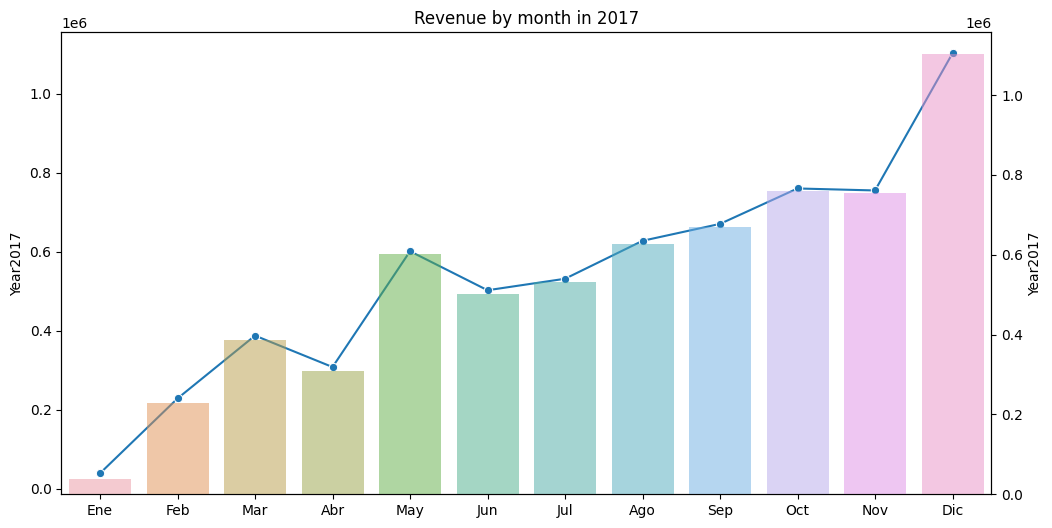

In [84]:
plot_revenue_by_month_year(revenue_by_month_year, 2017)

In [85]:
plot_top_10_revenue_categories(top_10_revenue_categories)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\USUARIO\AppData\Roaming\Python\Python39\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\USUARIO\AppData\Local\Temp\ipykernel_50556\2002395740.py", line 1, in <module>
    plot_top_10_revenue_categories(top_10_revenue_categories)
  File "c:\desarrollo\ProyectoIntegradorIV\proyecto_integrador_etl\src\plots.py", line 171, in plot_top_10_revenue_categories
    fig = px.treemap(df, path=["Category"], values="Num_order", width=800, height=400)
  File "c:\Users\USUARIO\AppData\Local\Programs\Python\Python39\lib\site-packages\plotly\express\_chart_types.py", line 1812, in treemap
    text=None,
  File "c:\Users\USUARIO\AppData\Local\Programs\Python\Python39\lib\site-packages\plotly\express\_core.py", line 2756, in make_figure
  File "c:\Users\USUARIO\AppData\Local\Programs\Python\Python39\lib\site-packages\plotly\graph_objs\_figure.py", line 787, in

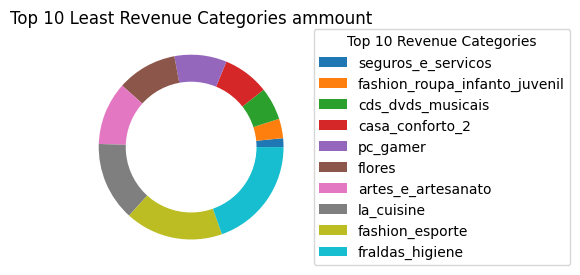

In [ ]:
plot_top_10_least_revenue_categories(top_10_least_revenue_categories)

In [ ]:
plot_revenue_per_state(revenue_per_state)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\USUARIO\AppData\Roaming\Python\Python39\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\USUARIO\AppData\Local\Temp\ipykernel_50556\1811210094.py", line 1, in <module>
    plot_revenue_per_state(revenue_per_state)
  File "c:\desarrollo\ProyectoIntegradorIV\proyecto_integrador_etl\src\plots.py", line 95, in plot_revenue_per_state
    fig = px.treemap(
  File "c:\Users\USUARIO\AppData\Local\Programs\Python\Python39\lib\site-packages\plotly\express\_chart_types.py", line 1812, in treemap
    text=None,
  File "c:\Users\USUARIO\AppData\Local\Programs\Python\Python39\lib\site-packages\plotly\express\_core.py", line 2756, in make_figure
  File "c:\Users\USUARIO\AppData\Local\Programs\Python\Python39\lib\site-packages\plotly\graph_objs\_figure.py", line 787, in update_layout
    -------
  File "c:\Users\USUARIO\AppData\Local\Programs\Python\Python39

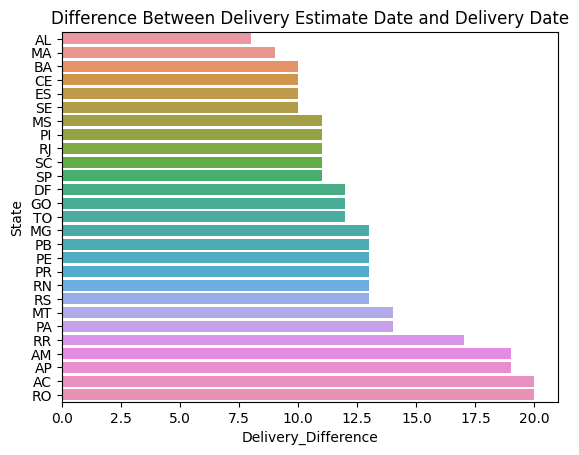

In [ ]:
plot_delivery_date_difference(delivery_date_difference)

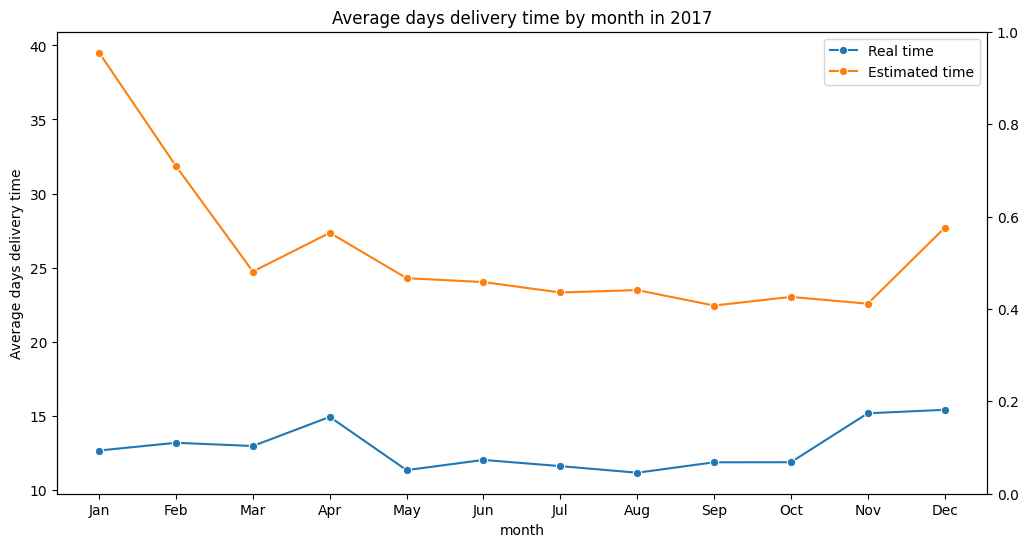

In [ ]:
plot_real_vs_predicted_delivered_time(real_vs_estimated_delivered_time, year=2017)

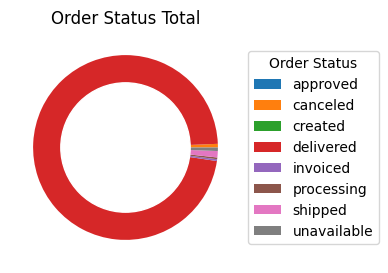

In [ ]:
plot_global_amount_order_status(global_ammount_order_status)

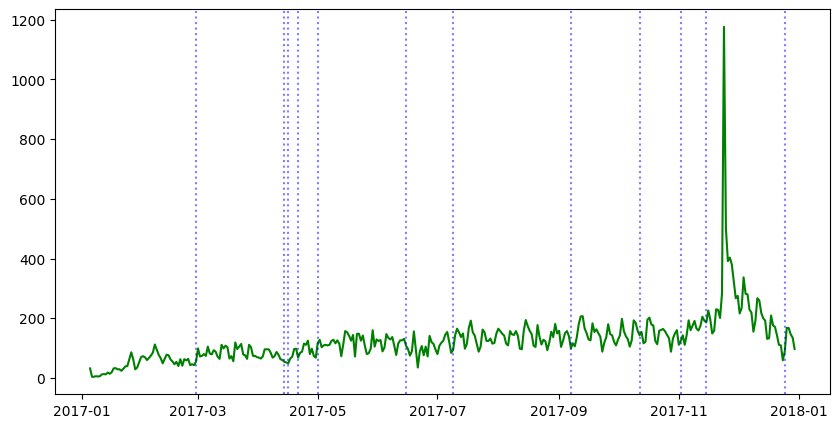

In [ ]:
plot_order_amount_per_day_with_holidays(orders_per_day_and_holidays)

El gráfico de Pedidos por Día y Días Festivos que programarás en **src/plots.py** debe ser similar a este:

![The plot you will code will be similar to this:](images/orders_per_day_and_holidays.png "Orders per Day and Holidays")

4.1 ¿Ves alguna relación entre los días festivos en Brasil durante 2017 y las compras de ese año?

Respuesta: ________

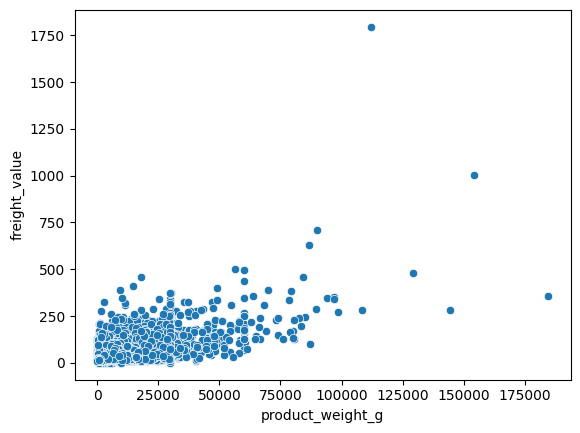

In [ ]:
plot_freight_value_weight_relationship(freight_value_weight_relationship)

El gráfico sobre la relación entre el valor del flete y el peso del producto que debes programar en `src/plots.py` tiene que ser similar a este:

![The plot you will code will be similar to this:](images/freight_value_weight_relationship.png "Freight Value and Weight Relationship")

4.2 ¿Ves alguna correlación entre el valor del flete y el peso del producto?

Respuesta:____